# Primena neuronskih mreža za detekciju prevara u transakcijama kreditnim karticama


## 1. Opis problema

Prevare u finansijskim transakcijama predstavljaju značajan problem za banke, platne sisteme, trgovce i korisnike platnih kartica. Cilj sistema za detekciju prevara jeste da na osnovu karakteristika transakcije prepozna da li je transakcija regularna ili potencijalno prevarna.

U projektu problem posmatramo kao problem binarne klasifikacije. Svaka transakcija pripada jednoj od dve klase:

- `0` — regularna transakcija
- `1` — prevarna transakcija

Za rešavanje problema koristi se neuronska mreža koja na osnovu ulaznih atributa transakcije predviđa verovatnoću da je transakcija prevara.

Poseban izazov ovog problema jeste velika neuravnoteženost klasa. U realnim finansijskim sistemima broj prevarnih transakcija je značajno manji od broja regularnih transakcija. Zbog toga sama tačnost modela nije dovoljna metrika za procenu uspešnosti. Model može imati visoku tačnost čak i ako većinu prevara ne prepozna. Zato se u ovom projektu koriste metrike kao što su precision, recall, F1-score, ROC-AUC i PR-AUC.


## 2. Podaci

### 2.1. Izvor podataka

U projektu koristi se javno dostupan dataset **Credit Card Fraud Detection**, preuzet sa platforme Kaggle.

Izvor podataka:
`https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud`


Dataset sadrži transakcije evropskih korisnika kreditnih kartica,  pri čemu je za svaku transakciju označeno da li je regularna ili prevarna. Zbog zaštite privatnosti korisnika, većina atributa je anonimizovana i transformisana pomoću PCA metode.
To znači da originalne karakteristike transakcija nisu direktno dostupne. Umesto konkretnih atributa, kao što bi mogli biti lokacija, tip trgovca ili identitet korisnika, dataset sadrži numeričke promenljive označene kao `V1`, `V2`, ..., `V28`.

### 2.2. Struktura podataka

Dataset se nalazi u CSV fajlu `creditcard.csv`.

Kolone u datasetu su:

- `Time` — vreme proteklo od prve transakcije u datasetu
- `V1` do `V28` — anonimizovane numeričke karakteristike dobijene PCA transformacijom
- `Amount` — iznos transakcije
- `Class` — ciljna promenljiva

Ciljna promenljiva `Class` ima dve moguće vrednosti:

- `0` — regularna transakcija
- `1` — prevarna transakcija

Dakle, cilj modela je da na osnovu kolona `Time`, `Amount` i `V1–V28` predvidi vrednost kolone `Class`.

### 2.3. Analiza podataka

Pre treniranja modela potrebno je analizirati osnovne karakteristike podataka.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
df = pd.read_csv("data/creditcard.csv")

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.shape

(284807, 31)

Dataset ima 284.807 redova i 31 kolonu. Svaki red predstavlja jednu transakciju, dok kolone predstavljaju atribute transakcije i ciljnu promenljivu.

Od 31 kolone, 30 kolona predstavljaju ulazne atribute (`Time`, `Amount` i `V1–V28`), dok kolona `Class` predstavlja izlaznu promenljivu koju model treba da predvidi.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

Na osnovu prikaza informacija o datasetu vidi se da su sve kolone numeričkog tipa. Većina kolona je tipa `float64`, dok je ciljna promenljiva `Class` celobrojnog tipa.

In [6]:
df.isnull().sum()


Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Ukupan broj nedostajućih vrednosti u datasetu je 0. To znači da nema praznih (`NaN`) vrednosti koje bi trebalo popunjavati ili uklanjati.

In [7]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


Na osnovu deskriptivne statistike vidi se da kolone `Time` i `Amount` imaju znatno drugačije skale vrednosti u odnosu na kolone `V1–V28`. Prema opisu dataseta, kolone `V1–V28` su već anonimizovane i PCA-transformisane, dok `Time` i `Amount` nisu transformisane na isti način. Zbog toga će u fazi preprocesiranja biti potrebno skalirati kolone `Time` i `Amount`.

In [8]:
class_counts = df["Class"].value_counts()
class_counts

Class
0    284315
1       492
Name: count, dtype: int64

Raspodela ciljne promenljive pokazuje da postoji veoma velika neuravnoteženost klasa. Regularnih transakcija ima 284.315, dok prevarnih transakcija ima samo 492.

To znači da su prevare veoma retke u odnosu na regularne transakcije. Ovaj podatak je veoma važan za izbor metrika evaluacije i način treniranja modela.

In [9]:
class_percentages = df["Class"].value_counts(normalize=True) * 100
class_percentages

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

Procentualna raspodela pokazuje da regularne transakcije čine približno 99,83% dataseta, dok prevare čine samo oko 0,17%.

Zbog ovakve raspodele, tačnost nije dovoljna metrika za procenu modela. Model koji bi svaku transakciju označio kao regularnu imao bi veoma visoku tačnost, ali ne bi bio koristan jer ne bi otkrio prevare.

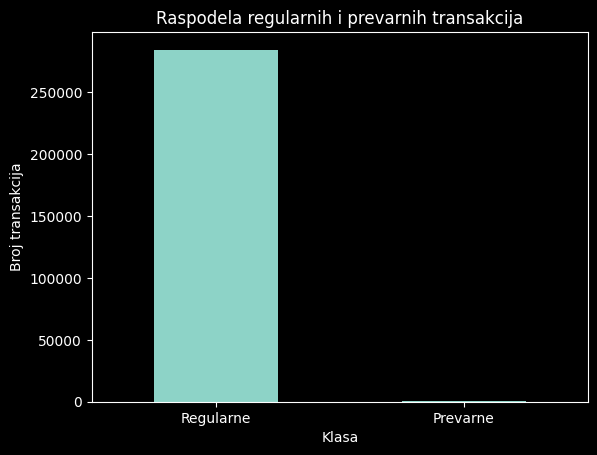

In [10]:
class_counts.plot(kind="bar")

plt.title("Raspodela regularnih i prevarnih transakcija")
plt.xlabel("Klasa")
plt.ylabel("Broj transakcija")
plt.xticks(ticks=[0, 1], labels=["Regularne", "Prevarne"], rotation=0)
plt.show()

Grafički prikaz dodatno potvrđuje da je dataset izrazito neuravnotežen.

Ova neuravnoteženost može dovesti do toga da model tokom treninga favorizuje većinsku klasu. Zbog toga ćemo kasnije koristiti metrike kao što su precision, recall, F1-score, ROC-AUC i PR-AUC, kao i tehniku ponderisanja klasa.

### 2.4. Preprocesiranje podataka



#### 2.4.1. Razdvajanje ulaznih atributa i ciljne promenljive

Prvi korak je razdvajanje dataseta na ulazne atribute i ciljnu promenljivu.
Ulazni atributi su sve kolone osim `Class`, dok je `Class` ciljna promenljiva koju model treba da predvidi.

In [11]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("Dimenzije ulaznih atributa:", X.shape)
print("Dimenzije ciljne promenljive:", y.shape)

Dimenzije ulaznih atributa: (284807, 30)
Dimenzije ciljne promenljive: (284807,)


Nakon razdvajanja podataka, skup ulaznih atributa `X` ima 284.807 redova i 30 kolona. To znači da za svaku transakciju imamo 30 ulaznih karakteristika.

Ciljna promenljiva `y` ima 284.807 vrednosti, po jednu za svaku transakciju. Svaka vrednost označava da li je transakcija regularna ili prevarna.

#### 2.4.2. Podela podataka na trening i test skup

Dataset delimo na trening i test skup. Trening skup se koristi za učenje modela, dok se test skup koristi tek na kraju za procenu kvaliteta modela na podacima koje model nije video tokom treninga.

Koristimo stratifikovanu podelu, što znači da se odnos regularnih i prevarnih transakcija čuva i u trening i u test skupu. Ovo je posebno važno kod neuravnoteženih podataka, jer želimo da i trening i test skup sadrže približno isti procenat prevara.

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (227845, 30)
X_test: (56962, 30)
y_train: (227845,)
y_test: (56962,)


Podaci su podeljeni tako da se 80% transakcija koristi za trening, a 20% za testiranje.
Trening skup sadrži 227.845 transakcija, dok test skup sadrži 56.962 transakcije.

#### 2.4.3. Provera raspodele klasa nakon podele

Nakon podele proveravamo da li je stratifikacija sačuvala odnos klasa u trening i test skupu.


In [14]:
print("Raspodela klasa u trening skupu:")
print(y_train.value_counts(normalize=True) * 100)

print("\nRaspodela klasa u test skupu:")
print(y_test.value_counts(normalize=True) * 100)

Raspodela klasa u trening skupu:
Class
0    99.827075
1     0.172925
Name: proportion, dtype: float64

Raspodela klasa u test skupu:
Class
0    99.827955
1     0.172045
Name: proportion, dtype: float64


Raspodela klasa u trening i test skupu je gotovo ista kao u originalnom datasetu. Regularne transakcije čine približno 99,83%, dok prevare čine približno 0,17% podataka.

Ovo potvrđuje da je stratifikovana podela uspešno sačuvala odnos klasa. To je važno zato što test skup treba da predstavlja realnu raspodelu podataka.

#### 2.4.4. Skaliranje kolona `Time` i `Amount`

Kolone `Time` i `Amount` imaju drugačije skale vrednosti od PCA-transformisanih kolona `V1–V28`. Zbog toga ih standardizujemo pomoću `StandardScaler`.

Standardizacija transformiše vrednosti tako da imaju približno srednju vrednost 0 i standardnu devijaciju 1.

Važno je da se `StandardScaler` uči samo na trening skupu, a zatim se ista transformacija primenjuje na test skup. Na taj način se sprečava curenje informacija iz test skupa u trening proces.

In [15]:
from sklearn.preprocessing import StandardScaler

In [16]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[["Time", "Amount"]] = scaler.fit_transform(X_train[["Time", "Amount"]])
X_test_scaled[["Time", "Amount"]] = scaler.transform(X_test[["Time", "Amount"]])

In [17]:
X_train_scaled[["Time", "Amount"]].describe()

,Time,Amount
count,2.278450e+05,2.278450e+05
mean,-1.409578e-16,3.742243e-17
std,1.000002e+00,1.000002e+00
min,-1.998073e+00,-3.516894e-01
25%,-8.561495e-01,-3.291944e-01
50%,-2.122647e-01,-2.639429e-01
75%,9.366285e-01,-4.262209e-02
max,1.640549e+00,1.021170e+02


Nakon skaliranja, kolone `Time` i `Amount` u trening skupu imaju srednju vrednost približno 0 i standardnu devijaciju približno 1.

Ovo pomaže neuronskoj mreži da stabilnije i efikasnije uči, jer ulazne promenljive nemaju velike razlike u skalama.

#### 2.4.5. Priprema pondera klasa

Zbog velike neuravnoteženosti dataseta, model može da nauči da favorizuje regularne transakcije, jer one čine skoro ceo dataset.
Da se to ublaži, koristićemo pondere klasa. Ideja je da greška na retkoj klasi, odnosno prevarnim transakcijama, ima veću težinu tokom treninga modela.

In [18]:
from sklearn.utils.class_weight import compute_class_weight

In [19]:
class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=y_train
)

class_weights = {
    0: class_weights_values[0],
    1: class_weights_values[1]
}

class_weights

{0: np.float64(0.5008661206149896), 1: np.float64(289.14340101522845)}

Dobijeni ponderi pokazuju da regularna klasa ima malu težinu, dok prevarna klasa ima mnogo veću težinu.

To znači da će model tokom treninga biti jače kažnjen kada pogrešno klasifikuje prevarnu transakciju. Ovo je korisno jer su prevare veoma retke i postoji rizik da ih model ignoriše ako se sve greške tretiraju jednako.

## 3. Arhitektura modela

Za rešavanje problema koristi se neuronska mreža za binarnu klasifikaciju. Ulaz u model predstavljaju atributi transakcije, dok izlaz modela predstavlja verovatnoću da je transakcija prevarna.

Pošto je ciljna promenljiva `Class` binarna, model ima jedan izlazni neuron sa sigmoid aktivacionom funkcijom. Sigmoid funkcija vraća vrednost između 0 i 1, pa se izlaz modela može tumačiti kao procenjena verovatnoća pripadnosti klasi `1`, odnosno klasi prevarnih transakcija.

Arhitektura modela sastoji se od:

- ulaznog sloja koji prima 30 atributa
- dva potpuno povezana skrivena sloja
- `Dropout` slojeva za smanjenje preprilagođavanja
- izlaznog sloja sa jednim neuronom i sigmoid aktivacijom

In [20]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.keras.utils.set_random_seed(RANDOM_STATE)


In [21]:
def create_model(input_dim):
    tf.keras.utils.set_random_seed(RANDOM_STATE)
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),

        layers.Dense(32, activation="relu"),
        layers.Dropout(0.3),

        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="auc")
        ]
    )

    return model

In [22]:
model = create_model(input_dim=X_train_scaled.shape[1])

In [23]:
for i, layer in enumerate(model.layers):
    print(f"{i+1}. {layer.name} - {layer.__class__.__name__}")
    print(f"   Output shape: {layer.output.shape}")
    print(f"   Parameters: {layer.count_params()}")

1. dense - Dense
   Output shape: (None, 64)
   Parameters: 1984
2. dropout - Dropout
   Output shape: (None, 64)
   Parameters: 0
3. dense_1 - Dense
   Output shape: (None, 32)
   Parameters: 2080
4. dropout_1 - Dropout
   Output shape: (None, 32)
   Parameters: 0
5. dense_2 - Dense
   Output shape: (None, 1)
   Parameters: 33


Prikaz arhitekture pokazuje da model ima dva skrivena `Dense` sloja, dva `Dropout` sloja i jedan izlazni sloj.

Prvi skriveni sloj ima 64 neurona i 1984 parametra. Drugi skriveni sloj ima 32 neurona i 2080 parametara. Izlazni sloj ima jedan neuron i 33 parametra.
Izlazni sloj ima jedan neuron zato što se rešava problem binarne klasifikacije. Taj neuron prima 32 vrednosti iz prethodnog sloja i računa jednu linearnu kombinaciju tih vrednosti. Nakon toga se primenjuje sigmoid aktivaciona funkcija, koja rezultat transformiše u vrednost između 0 i 1.
Dobijena vrednost predstavlja procenjenu verovatnoću da je transakcija prevarna. Da bi se verovatnoća pretvorila u konačnu klasu, koristi se prag klasifikacije. Ako je verovatnoća veća ili jednaka 0.5, transakcija se klasifikuje kao prevarna, dok se u suprotnom klasifikuje kao regularna.

`Dropout` slojevi tokom treninga nasumično isključuju deo neurona kako bi se smanjio rizik od preprilagođavanja.

Ukupno, model ima 4097 parametara koji se uče tokom treninga.

## 4. Trening

Tokom treninga model prolazi kroz trening podatke, pravi predikcije, računa grešku i zatim podešava težine i bias vrednosti pomoću backpropagation algoritma i optimizatora.

Za trening se koriste skalirani trening podaci `X_train_scaled` i ciljna promenljiva `y_train`.

Zbog neuravnoteženosti klasa koristi se `class_weight`, kako bi greške na prevarnim transakcijama imale veću težinu. Pored toga, koristi se `EarlyStopping`, koji zaustavlja trening kada se performanse na validacionom skupu više ne poboljšavaju.

### 4.1. Early stopping

`EarlyStopping` je tehnika koja prati performanse modela na validacionom skupu tokom treninga. Ako se AUC vrednost ne poboljšava 5 uzastopnih epoha, trening se automatski zaustavlja.

Ovo je korisno jer sprečava nepotrebno dugo treniranje i smanjuje rizik od preprilagođavanja modela trening podacima.

In [24]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_auc",
    patience=5,
    mode="max",
    restore_best_weights=True
)


Pošto je cilj da AUC bude što veći, model pamti onu epohu u kojoj je ostvarena najbolja validaciona AUC vrednost. Nakon završetka treninga vraćaju se težine iz te najbolje epohe.


### 4.2. Treniranje modela

In [25]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=2048,
    class_weight=class_weights,
    callbacks=[early_stopping],
    shuffle=False,
    verbose=1
)

90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - auc: 0.9914 - loss: 0.1184 - precision: 0.0474 - recall: 0.9293 - val_auc: 0.9903 - val_loss: 0.0821 - val_precision: 0.0600 - val_recall: 0.9036


Maksimalan broj prolazaka kroz trening podatke je 50. Međutim, model ne mora nužno trenirati svih 50 epoha, jer se koristi `EarlyStopping`. Ako se performanse na validacionom skupu prestanu poboljšavati, trening se može zaustaviti ranije.

U jednom koraku treninga model obrađuje 2048 transakcija. Ova vrednost predstavlja veličinu batch-a. Pošto dataset ima veliki broj transakcija, veći batch omogućava brži trening, ali model i dalje uči postepeno kroz više koraka.

Tokom treninga 20% trening podataka odvaja se za validaciju. Validacioni skup se koristi za praćenje performansi modela tokom treninga, ali se ne koristi za direktno podešavanje težina modela.

Zbog velike neuravnoteženosti klasa koriste se prethodno izračunati ponderi klasa. Na taj način greške na prevarnim transakcijama imaju veću težinu od grešaka na regularnim transakcijama, što pomaže modelu da obrati više pažnje na retku klasu.


### 4.3. Prikaz toka treninga

Nakon treniranja prikazujemo kako su se tokom epoha menjale vrednosti funkcije greške i AUC metrike.

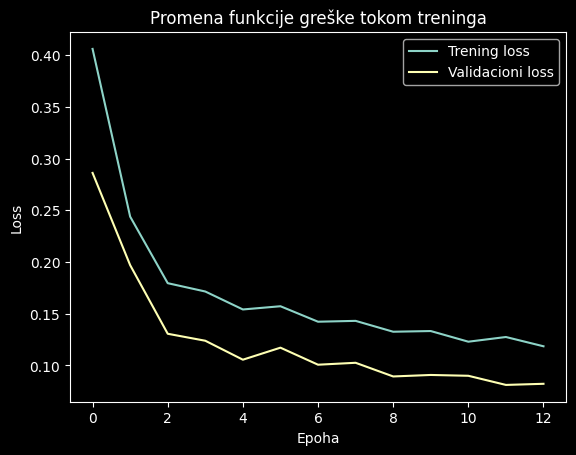

In [26]:
plt.plot(history.history["loss"], label="Trening loss")
plt.plot(history.history["val_loss"], label="Validacioni loss")

plt.title("Promena funkcije greške tokom treninga")
plt.xlabel("Epoha")
plt.ylabel("Loss")
plt.legend()
plt.show()

Na grafikonu se vidi da se funkcija greške na trening skupu naglo smanjuje u prvim epohama, a zatim se postepeno stabilizuje. To pokazuje da model tokom treninga uči obrasce iz podataka i smanjuje grešku predikcije.

Validacioni loss se takođe smanjuje i ostaje niži od trening loss-a tokom većeg dela treninga. To ukazuje da model ne pokazuje izražene znake preprilagođavanja trening podacima.

Model je trenirao 13 epoha, iako je maksimalan broj epoha bio postavljen na 50. Trening je ranije zaustavljen pomoću `EarlyStopping` tehnike, jer se validaciona AUC vrednost više nije poboljšavala dovoljno kroz naredne epohe.

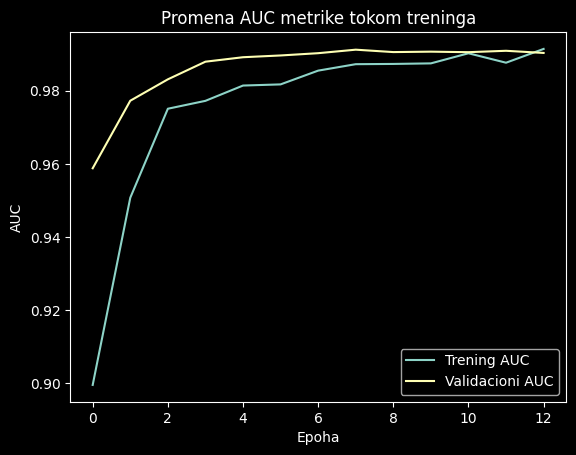

In [27]:
plt.plot(history.history["auc"], label="Trening AUC")
plt.plot(history.history["val_auc"], label="Validacioni AUC")

plt.title("Promena AUC metrike tokom treninga")
plt.xlabel("Epoha")
plt.ylabel("AUC")
plt.legend()
plt.show()

Na grafikonu se vidi da AUC vrednost brzo raste u prvim epohama, što pokazuje da model već na početku treninga uči da razlikuje regularne i prevarne transakcije.

Trening AUC i validacioni AUC se nakon nekoliko epoha stabilizuju na visokim vrednostima, blizu 0.99. To ukazuje da model ima dobru sposobnost razdvajanja klasa.

Validacioni AUC je tokom treninga veoma blizak trening AUC vrednosti, što znači da model ne pokazuje izražene znake preprilagođavanja. Model ne uči samo napamet trening podatke, već zadržava dobre performanse i na validacionom skupu.


## 5. Analiza osetljivosti i hiperparametarska optimizacija

U ovom projektu analiziramo uticaj nekoliko hiperparametara na performanse modela:

- broj neurona u skrivenim slojevima
- dropout stopu
- learning rate

Cilj ove analize je da proverimo da li početna arhitektura modela predstavlja dobar izbor ili se boljim podešavanjem hiperparametara mogu dobiti bolje performanse.

In [28]:
def create_tuned_model(input_dim, hidden_layers=(64, 32), dropout_rate=0.3, learning_rate=0.001):
    tf.keras.utils.set_random_seed(RANDOM_STATE)
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))

    for neurons in hidden_layers:
        model.add(layers.Dense(neurons, activation="relu"))
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="auc")
        ]
    )

    return model

Ova funkcija služi za kreiranje neuronske mreže sa promenljivim hiperparametrima. Koristimo je jer želimo da testiramo više različitih arhitektura modela bez ponavljanja istog koda.

Unutar funkcije se prvo kreira sekvencijalni Keras model. Zatim se dodaju ulazni slojevi, Dense slojevi i Dropout slojevi. Na ovaj način ista funkcija može da napravi modele sa različitim brojem slojeva i neurona.
Na kraju se dodaje izlazni sloj sa jednim neuronom i sigmoid aktivacionom funkcijom.

Model se zatim kompajlira pomoću Adam optimizatora, `binary_crossentropy` funkcije greške i metrika `precision`, `recall` i `AUC`.

Funkcija vraća kreirani i kompajlirani model, spreman za treniranje.

In [29]:
experiments = [
    {
        "name": "Model 1: 32-16, dropout 0.3, lr 0.001",
        "hidden_layers": (32, 16),
        "dropout_rate": 0.3,
        "learning_rate": 0.001
    },
    {
        "name": "Model 2: 64-32, dropout 0.3, lr 0.001",
        "hidden_layers": (64, 32),
        "dropout_rate": 0.3,
        "learning_rate": 0.001
    },
    {
        "name": "Model 3: 128-64, dropout 0.3, lr 0.001",
        "hidden_layers": (128, 64),
        "dropout_rate": 0.3,
        "learning_rate": 0.001
    },
    {
        "name": "Model 4: 64-32, dropout 0.5, lr 0.001",
        "hidden_layers": (64, 32),
        "dropout_rate": 0.5,
        "learning_rate": 0.001
    },
    {
        "name": "Model 5: 64-32, dropout 0.3, lr 0.0005",
        "hidden_layers": (64, 32),
        "dropout_rate": 0.3,
        "learning_rate": 0.0005
    }
]

U prvom eksperimentu testira se jednostavniji model sa manje neurona. Takav model ima manji broj parametara i manji rizik od preprilagođavanja, ali može imati nedovoljan kapacitet da nauči složenije obrasce.

Drugi eksperiment predstavlja početnu arhitekturu korišćenu u prethodnom delu projekta.

Treći eksperiment koristi veći broj neurona, čime se povećava kapacitet modela. Takav model može naučiti složenije odnose u podacima, ali može imati veći rizik od preprilagođavanja.

Četvrti eksperiment zadržava istu arhitekturu kao početni model, ali povećava dropout stopu na 0.5. Time se jače sprečava preprilagođavanje, ali preveliki dropout može otežati učenje.

Peti eksperiment koristi istu arhitekturu kao početni model, ali manji learning rate. Manji learning rate može omogućiti stabilnije učenje, ali trening može biti sporiji.

In [30]:
tuning_results = []

for experiment in experiments:

    tuned_model = create_tuned_model(
        input_dim=X_train_scaled.shape[1],
        hidden_layers=experiment["hidden_layers"],
        dropout_rate=experiment["dropout_rate"],
        learning_rate=experiment["learning_rate"]
    )

    early_stopping_tuning = keras.callbacks.EarlyStopping(
        monitor="val_auc",
        patience=3,
        mode="max",
        restore_best_weights=True
    )

    history_tuned = tuned_model.fit(
        X_train_scaled,
        y_train,
        validation_split=0.2,
        epochs=30,
        batch_size=2048,
        class_weight=class_weights,
        callbacks=[early_stopping_tuning],
        shuffle=False,
        verbose=0
    )

    best_epoch = np.argmax(history_tuned.history["val_auc"])

    best_val_auc = history_tuned.history["val_auc"][best_epoch]
    best_val_precision = history_tuned.history["val_precision"][best_epoch]
    best_val_recall = history_tuned.history["val_recall"][best_epoch]
    epochs_trained = len(history_tuned.history["loss"])

    tuning_results.append({
        "Model": experiment["name"],
        "Hidden layers": experiment["hidden_layers"],
        "Dropout": experiment["dropout_rate"],
        "Learning rate": experiment["learning_rate"],
        "Best val AUC": best_val_auc,
        "Best val precision": best_val_precision,
        "Best val recall": best_val_recall,
        "Epochs trained": epochs_trained
    })



In [31]:
tuning_results_df = pd.DataFrame(tuning_results)
tuning_results_df.sort_values(by="Best val AUC", ascending=False)

,Model,Hidden layers,Dropout,Learning rate,Best val AUC,Best val precision,Best val recall,Epochs trained
2,"Model 3: 128-64, dropout 0.3, lr 0.001","(128, 64)",0.3,0.0010,0.991704,0.062449,0.927711,7
4,"Model 5: 64-32, dropout 0.3, lr 0.0005","(64, 32)",0.3,0.0005,0.991240,0.067144,0.903614,17
1,"Model 2: 64-32, dropout 0.3, lr 0.001","(64, 32)",0.3,0.0010,0.991237,0.050566,0.915663,11
0,"Model 1: 32-16, dropout 0.3, lr 0.001","(32, 16)",0.3,0.0010,0.988551,0.087108,0.903614,12
3,"Model 4: 64-32, dropout 0.5, lr 0.001","(64, 32)",0.5,0.0010,0.987789,0.057471,0.903614,11


Na osnovu rezultata hiperparametarske optimizacije vidi se da je najbolju validacionu AUC vrednost ostvario Model 3, sa arhitekturom `(128, 64)`, dropout stopom `0.3` i learning rate vrednošću `0.001`.

Model 3 ima validacioni AUC od približno 0.9917, što ukazuje na veoma dobru sposobnost razlikovanja regularnih i prevarnih transakcija. Takođe ima i najveći recall među testiranim modelima, približno 0.93, što znači da uspešno prepoznaje veliki procenat prevarnih transakcija.

Precision kod ovog modela iznosi približno 0.062, što je niska vrednost. To znači da među transakcijama koje model označi kao prevarne postoji značajan broj lažno pozitivnih slučajeva. Međutim, kod problema detekcije prevara je važnije pronaći što više stvarnih prevara, pa se recall posmatra kao važna metrika.

Model 1 ima najveći precision, ali nešto niži recall i AUC. To znači da je oprezniji kada označava transakciju kao prevarnu, ali zbog toga može propustiti veći broj stvarnih prevara.

Za završnu evaluaciju biramo Model 3, jer ostvaruje najbolji AUC i najveći recall na validacionom skupu. Ovaj izbor je u skladu sa ciljem projekta, jer je kod detekcije prevara posebno važno da model otkrije što veći broj prevarnih transakcija.

## 6. Rezultati evaluacije

Nakon hiperparametarske optimizacije, za završnu evaluaciju izabran je model sa arhitekturom `(128, 64)`, dropout stopom `0.3` i learning rate vrednošću `0.001`.

Evaluacija se vrši na test skupu, koji nije korišćen tokom treninga ni tokom izbora hiperparametara. Na taj način dobijamo objektivniju procenu performansi modela na novim podacima.

U evaluaciji posmatramo sledeće metrike:

- confusion matrix
- precision
- recall
- F1-score
- ROC-AUC
- PR-AUC

Pored toga, analiziramo i uticaj različitih pragova klasifikacije na odnos između precision i recall metrike.

In [32]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

In [33]:
best_model = create_tuned_model(
    input_dim=X_train_scaled.shape[1],
    hidden_layers=(128, 64),
    dropout_rate=0.3,
    learning_rate=0.001
)

In [34]:
early_stopping_best = keras.callbacks.EarlyStopping(
    monitor="val_auc",
    patience=5,
    mode="max",
    restore_best_weights=True
)

history_best = best_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=2048,
    class_weight=class_weights,
    callbacks=[early_stopping_best],
    verbose=1
)

90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - auc: 0.9937 - loss: 0.0983 - precision: 0.0622 - recall: 0.9518 - val_auc: 0.9892 - val_loss: 0.0768 - val_precision: 0.0753 - val_recall: 0.9277


Najbolji model je ponovo treniran korišćenjem izabranih hiperparametara: arhitektura `(128, 64)`, dropout stopa `0.3` i learning rate `0.001`.

Tokom treninga korišćen je `EarlyStopping`, pa model nije morao da trenira svih 50 epoha. Trening je zaustavljen kada se validaciona AUC vrednost više nije značajno poboljšavala.

In [35]:
y_test_proba = best_model.predict(X_test_scaled).ravel()

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 0s 156us/step


In [36]:
threshold = 0.5

y_test_pred = (y_test_proba >= threshold).astype(int)

U početnoj evaluaciji koristi se standardni prag klasifikacije od `0.5`. To znači da se transakcija klasifikuje kao prevarna ako model proceni verovatnoću prevare veću ili jednaku 0.5.

In [37]:
print(classification_report(y_test, y_test_pred, target_names=["Regularna", "Prevara"]))

              precision    recall  f1-score   support

   Regularna       1.00      0.97      0.98     56864
     Prevara       0.05      0.92      0.09        98

    accuracy                           0.97     56962
   macro avg       0.52      0.94      0.54     56962
weighted avg       1.00      0.97      0.98     56962



In [38]:
roc_auc = roc_auc_score(y_test, y_test_proba)
pr_auc = average_precision_score(y_test, y_test_proba)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")

ROC-AUC: 0.9790
PR-AUC: 0.6959


ROC-AUC meri sposobnost modela da razlikuje regularne i prevarne transakcije kroz različite pragove klasifikacije.

PR-AUC meri površinu ispod Precision-Recall krive. Kod izrazito neuravnoteženih podataka, kao što je ovaj dataset, PR-AUC je posebno korisna metrika jer se fokusira na kvalitet predikcija za retku klasu.

In [39]:
cm = confusion_matrix(y_test, y_test_pred)


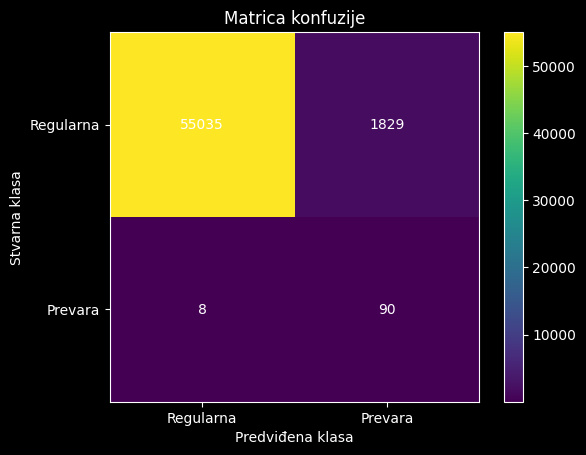

In [40]:
plt.imshow(cm)

plt.title("Matrica konfuzije")
plt.xlabel("Predviđena klasa")
plt.ylabel("Stvarna klasa")

plt.xticks([0, 1], ["Regularna", "Prevara"])
plt.yticks([0, 1], ["Regularna", "Prevara"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

Pri početnoj evaluaciji korišćen je standardni prag klasifikacije `0.5`.

Rezultati pokazuju da model ostvaruje visok recall za klasu `Prevara`. Recall iznosi približno `0.92`, što znači da model uspeva da otkrije oko 93% stvarnih prevarnih transakcija iz test skupa. Ovo je važan rezultat, jer je kod detekcije prevara cilj da se što manje stvarnih prevara propusti.

Međutim, precision za klasu `Prevara` iznosi približno `0.05`. To znači da od svih transakcija koje je model označio kao prevarne, samo oko 5% zaista predstavljaju prevare. Drugim rečima, model pri ovom pragu generiše veliki broj lažno pozitivnih slučajeva, odnosno regularnih transakcija koje pogrešno označava kao prevarne.

Ukupna tačnost modela iznosi približno `0.97`, ali ovu metriku treba tumačiti oprezno zbog velike neuravnoteženosti klasa. Pošto regularne transakcije čine skoro ceo dataset, visoka tačnost ne znači nužno da model dobro rešava problem detekcije prevara.

Matrica konfuzije dodatno potvrđuje ovaj zaključak. Model je uspešno prepoznao većinu prevara, ali je istovremeno veliki broj regularnih transakcija klasifikovao kao prevarne. Zbog toga je potrebno analizirati različite pragove klasifikacije kako bi se pronašao bolji odnos između precision i recall metrike.

In [41]:
thresholds = [0.1, 0.2, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95, 0.99]

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_test_proba >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "F1-score": f1_score(y_test, y_pred_threshold, zero_division=0),
        "Predicted frauds": y_pred_threshold.sum()
    })

threshold_results_df = pd.DataFrame(threshold_results)
threshold_results_df

,Threshold,Precision,Recall,F1-score,Predicted frauds
0,0.10,0.006692,0.969388,0.013291,14197
1,0.20,0.013617,0.959184,0.026853,6903
2,0.30,0.022393,0.948980,0.043754,4153
3,0.50,0.046899,0.918367,0.089241,1919
4,0.70,0.098234,0.908163,0.177291,906
5,0.80,0.131818,0.887755,0.229551,660
6,0.90,0.193333,0.887755,0.317518,450
7,0.95,0.390909,0.877551,0.540881,220
8,0.99,0.674797,0.846939,0.751131,123


Tabela prikazuje kako se menjaju precision, recall i F1-score za klasu `Prevara` pri različitim pragovima klasifikacije.

Pri nižim pragovima, kao što su `0.1`, `0.2` i `0.3`, model veoma lako označava transakcije kao prevarne. Zbog toga je recall veoma visok, što znači da model uspeva da pronađe veliki broj stvarnih prevara. Međutim, precision je veoma nizak, jer se veliki broj regularnih transakcija pogrešno označava kao prevara.

Pri standardnom pragu `0.5`, recall iznosi približno `0.918`, što znači da model otkriva oko 92% stvarnih prevara. Međutim, precision je samo oko `0.047`, pa model i dalje generiše veliki broj lažnih alarma.

Povećavanjem praga model postaje stroži. To znači da transakciju označava kao prevarnu samo ako je procenjena verovatnoća prevare veoma visoka. Zbog toga precision raste, dok recall postepeno opada.

Na primer, pri pragu `0.95`, precision raste na približno `0.391`, dok recall ostaje relativno visok i iznosi približno `0.878`. To predstavlja bolji balans u odnosu na prag `0.5`, jer model značajno smanjuje broj lažnih alarma, a i dalje uspeva da otkrije veliki deo stvarnih prevara.

Pri pragu `0.99`, precision dodatno raste na približno `0.675`, ali recall opada na približno `0.847`. To znači da model pravi manje lažnih alarma, ali propušta više stvarnih prevara nego pri pragu `0.95`.

Na osnovu ove analize, prag `0.95` predstavlja dobar kompromis između precision i recall metrika. Zbog toga se u nastavku evaluacije koristi prag `0.95` kao izabrani prag klasifikacije.

### 6.1. Evaluacija sa izabranim pragom klasifikacije

Na osnovu analize različitih pragova klasifikacije, izabran je prag `0.95`. Ovaj prag predstavlja bolji kompromis između precision i recall metrika u odnosu na standardni prag `0.5`.

Pri pragu `0.5` model prepoznaje veliki broj prevara, ali generiše mnogo lažnih alarma. Povećanjem praga na `0.95`, model postaje stroži pri označavanju transakcije kao prevarne, čime se značajno povećava precision, dok recall ostaje relativno visok.

In [42]:
selected_threshold = 0.95

y_test_pred_selected = (y_test_proba >= selected_threshold).astype(int)

In [43]:
print(classification_report(
    y_test,
    y_test_pred_selected,
    target_names=["Regularna", "Prevara"]
))

              precision    recall  f1-score   support

   Regularna       1.00      1.00      1.00     56864
     Prevara       0.39      0.88      0.54        98

    accuracy                           1.00     56962
   macro avg       0.70      0.94      0.77     56962
weighted avg       1.00      1.00      1.00     56962



Pri ovom pragu model ostvaruje znatno bolji precision za klasu `Prevara` u odnosu na standardni prag `0.5`. Precision za klasu `Prevara` iznosi `0.39`, što znači da je oko 39% transakcija koje je model označio kao prevarne zaista prevarno.

Recall za klasu `Prevara` iznosi `0.88`, što znači da model uspeva da otkrije oko 88% stvarnih prevara iz test skupa. U poređenju sa pragom `0.5`, recall je malo manji, ali je precision značajno bolji.

F1-score za klasu `Prevara` iznosi `0.54`, što je znatno bolje nego kod standardnog praga. To pokazuje da prag `0.95` daje bolji balans između precision i recall metrika.

Ukupna accuracy je veoma visoka, ali se kod ovog problema ne oslanjamo samo na accuracy zbog velike neuravnoteženosti klasa. Mnogo je važnije posmatrati ponašanje modela nad klasom `Prevara`, jer je ona retka i predstavlja glavni cilj detekcije.

In [44]:
cm_selected = confusion_matrix(y_test, y_test_pred_selected)

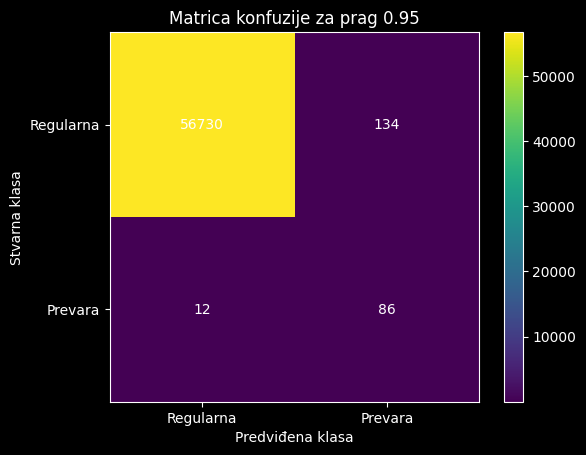

In [45]:
plt.imshow(cm_selected)

plt.title("Matrica konfuzije za prag 0.95")
plt.xlabel("Predviđena klasa")
plt.ylabel("Stvarna klasa")

plt.xticks([0, 1], ["Regularna", "Prevara"])
plt.yticks([0, 1], ["Regularna", "Prevara"])

for i in range(cm_selected.shape[0]):
    for j in range(cm_selected.shape[1]):
        plt.text(j, i, cm_selected[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

Matrica konfuzije za prag `0.95` pokazuje da je model od 98 stvarnih prevarnih transakcija uspešno prepoznao 86, dok je 12 prevara klasifikovao kao regularne transakcije.

Takođe, model je 134 regularne transakcije pogrešno označio kao prevarne. To su lažno pozitivni slučajevi, odnosno lažni alarmi. U odnosu na prag `0.5`, broj lažnih alarma je značajno smanjen.

Ovi rezultati pokazuju da prag `0.95` predstavlja bolji kompromis za ovaj problem. Model i dalje uspešno otkriva veliki broj prevara, ali pravi mnogo manje lažno pozitivnih predikcija nego pri standardnom pragu `0.5`.


## 7. Diskusija

Rezultati pokazuju da neuronska mreža može uspešno da nauči obrasce koji razlikuju regularne i prevarne transakcije. Model ostvaruje visoke vrednosti ROC-AUC i PR-AUC metrika, što ukazuje da dobro rangira transakcije prema verovatnoći prevare.

Međutim, zbog izrazite neuravnoteženosti podataka, evaluacija modela nije jednostavna. Regularne transakcije čine skoro ceo dataset, dok je broj prevarnih transakcija veoma mali. Zbog toga accuracy nije dovoljna metrika za procenu kvaliteta modela. Model može imati visoku accuracy čak i ako ne detektuje prevare dovoljno dobro.

Pri standardnom pragu klasifikacije `0.5`, model ostvaruje visok recall za klasu `Prevara`, ali veoma nizak precision. To znači da uspešno pronalazi veliki broj stvarnih prevara, ali istovremeno generiše mnogo lažnih alarma. Ovakav model može biti koristan ako je glavni cilj da se propusti što manje prevara, ali u realnom sistemu veliki broj lažnih alarma može opteretiti proces dodatne provere transakcija.

Analizom različitih pragova klasifikacije pokazano je da se precision može značajno poboljšati povećanjem praga. Izabrani prag `0.95` daje bolji balans između precision i recall metrika. Model pri ovom pragu pravi manje lažno pozitivnih predikcija, dok i dalje uspeva da otkrije veliki deo stvarnih prevara.

Hiperparametarska optimizacija pokazala je da izbor arhitekture, dropout stope i learning rate vrednosti utiče na performanse modela. Najbolje rezultate ostvario je model sa arhitekturom `(128, 64)`, dropout stopom `0.3` i learning rate vrednošću `0.001`. Ovaj model je imao najbolji odnos posmatranih metrika na validacionom skupu.

Glavno ograničenje projekta jeste to što su atributi `V1–V28` anonimizovani PCA transformacijom. Zbog toga nije moguće direktno interpretirati značenje pojedinačnih atributa i objasniti, na primer, koji konkretni faktor transakcije najviše utiče na predikciju prevare. Ovo je čest problem kod finansijskih podataka, jer se zbog privatnosti korisnika originalne karakteristike ne objavljuju.

 Takođe, u realnoj primeni bilo bi važno uključiti dodatne informacije, kao što su istorija korisnika, lokacija, tip trgovca i vremenski obrasci ponašanja.

## 8. Zaključak

U ovom projektu razvijen je model neuronske mreže za detekciju prevara u transakcijama kreditnim karticama. Problem je formulisan kao binarna klasifikacija, gde model za svaku transakciju predviđa da li je regularna ili prevarna.

Korišćen je javno dostupan dataset `Credit Card Fraud Detection`, koji sadrži izrazito neuravnotežene podatke. Zbog toga je posebna pažnja posvećena izboru metrika evaluacije. Korišćene su precision, recall, F1-score, ROC-AUC, PR-AUC i matrica konfuzije.

Tokom preprocesiranja podaci su podeljeni na trening i test skup, skalirane su kolone `Time` i `Amount`, a zbog neuravnoteženosti klasa korišćeni su ponderi klasa. Model je implementiran pomoću TensorFlow/Keras biblioteke i sastoji se od potpuno povezanih `Dense` slojeva, `Dropout` regularizacije i izlaznog sloja sa sigmoid aktivacionom funkcijom.

Hiperparametarskom optimizacijom testirano je više konfiguracija modela. Najbolji rezultati dobijeni su za arhitekturu `(128, 64)`, dropout stopu `0.3` i learning rate `0.001`.

Evaluacija je pokazala da model može uspešno da detektuje veliki broj prevarnih transakcija. Pri standardnom pragu `0.5` model ima visok recall, ali nizak precision, što znači da otkriva većinu prevara, ali pravi veliki broj lažnih alarma. Analizom pragova klasifikacije izabran je prag `0.95`, koji daje bolji balans između precision i recall metrika.

Zaključno, neuronske mreže mogu biti korisne za detekciju finansijskih prevara, posebno kada se kombinuju sa odgovarajućim preprocesiranjem, ponderisanjem klasa i pažljivim izborom praga klasifikacije. Ipak, za realnu primenu bilo bi potrebno dodatno testiranje na novijim i raznovrsnijim podacima, kao i uključivanje dodatnih objašnjivih atributa transakcija.